6. Decision Trees and Ensemble Learning

6.1 Credit risk scoring project

In [257]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

6.2 Data cleaning and preparation

- Downloading the dataset
- Re-encoding the categorical variables
- Doing the train/validation/test split

In [258]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'

In [259]:
#!wget $data

In [260]:
#!head CreditScoring.csv

In [261]:
df = pd.read_csv(data)

In [262]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [263]:
df.columns = df.columns.str.lower()

In [264]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [265]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [266]:
status_values = {1: 'ok', 2: 'default', 0: 'unk' }

df.status = df.status.map(status_values)

In [267]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [268]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [269]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [270]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [271]:
df.income.replace(to_replace=99999999, value=np.nan).max()

np.float64(959.0)

In [272]:
for c in ['income', 'assets','debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [273]:
df.status.value_counts()

status
ok         3200
default    1254
unk           1
Name: count, dtype: int64

In [274]:
df[df.status != 'unk'].reset_index(drop=True)

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [275]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df,test_size = 0.2, random_state = 11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [276]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [277]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [278]:
del df_train['status']
del df_val['status']
del df_test['status']

In [279]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,3,rent,36,61,married,no,fixed,41,57.0,12000.0,0.0,2500,3559
1,5,rent,48,30,separated,yes,partime,39,41.0,0.0,0.0,1300,1600
2,15,owner,60,32,divorced,no,freelance,35,0.0,6000.0,3300.0,1550,1612
3,2,rent,12,47,married,yes,fixed,103,426.0,0.0,0.0,350,450
4,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2668,1,parents,60,21,single,no,partime,35,45.0,0.0,0.0,400,904
2669,5,rent,60,47,single,yes,fixed,46,106.0,8500.0,0.0,2500,2664
2670,23,rent,24,47,single,no,fixed,44,86.0,0.0,0.0,350,975
2671,5,owner,60,58,married,no,freelance,45,93.0,45000.0,0.0,1500,2090


6.3 Decision trees
- How a decision tree looks like
- Training a decision tree
- Overfitting
- Controlling the size of a tree


In [280]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets']>6000:
            return 'ok'
        else: 
           return 'default' 

In [281]:
xi = df_train.iloc[0].to_dict()

In [282]:
xi

{'seniority': 3,
 'home': 'rent',
 'time': 36,
 'age': 61,
 'marital': 'married',
 'records': 'no',
 'job': 'fixed',
 'expenses': 41,
 'income': 57.0,
 'assets': 12000.0,
 'debt': 0.0,
 'amount': 2500,
 'price': 3559}

In [283]:
assess_risk(xi)


'ok'

In [284]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

In [285]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [286]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [287]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [288]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [289]:
y_pred =dt.predict_proba(X_val)[:,1]

In [290]:
roc_auc_score(y_val, y_pred)

0.6621373564568165

In [291]:
y_pred =dt.predict_proba(X_train)[:,1]
roc_auc_score(y_train, y_pred)

1.0

In [292]:
dt = DecisionTreeClassifier(max_depth = 3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [293]:
y_pred = dt.predict_proba(X_train)[:,1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

train: 0.7660925386129352


In [294]:
y_pred = dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

val: 0.763427236430611


In [295]:
from sklearn.tree import export_text

print(export_text(dt, feature_names=dv.get_feature_names_out()))


|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 73.50
|   |   |   |--- class: 0
|   |   |--- income >  73.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- time <= 27.00
|   |   |   |--- class: 0
|   |   |--- time >  27.00
|   |   |   |--- class: 1
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- income <= 50.50
|   |   |   |--- class: 1
|   |   |--- income >  50.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 99.50
|   |   |   |--- class: 1
|   |   |--- income >  99.50
|   |   |   |--- class: 0



6.4 Decision tree learning algorithm
- Finding the best split for one column
- Finding the best split for the entire dataset
- Stopping criteria
- Decision tree learning algorithm


In [296]:
data =[
[8000, 'default'],
[2000, 'default'],
[0, 'default'],
[5000, 'ok'],
[5000, 'ok'],
[4000, 'ok'],
[9000, 'ok'],
[3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets','status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [297]:
df_example.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


In [298]:
Ts =[0,2000, 3000, 4000, 5000, 8000]

In [299]:
from IPython.display import display

In [300]:
for T in Ts:
    print(T)
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))
    
    


0


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64
2000


,assets,status
1,2000,default
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64
3000


,assets,status
1,2000,default
2,0,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64
4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64
5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64


6.5 Decision trees parameter tuning
- selecting max_depth
- selecting min_samples_leaf 

In [301]:
for d in [1,2,3,4,5,6,10,15,20,None]:
   dt = DecisionTreeClassifier(max_depth=d)
   dt.fit(X_train, y_train)

   y_pred = dt.predict_proba(X_val)[:,1]
   auc = roc_auc_score(y_val,y_pred)

   print('%4s -> %.3f'% (d,auc))
   

   1 -> 0.613
   2 -> 0.688
   3 -> 0.763


   4 -> 0.779
   5 -> 0.784
   6 -> 0.775
  10 -> 0.698
  15 -> 0.672
  20 -> 0.667
None -> 0.669


In [302]:
scores = []

for d in [4,5,6]:
   for s in [1,2,5,10,15,20,100,200,500]:
       dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
       dt.fit(X_train, y_train)

       y_pred = dt.predict_proba(X_val)[:,1]
       auc = roc_auc_score(y_val,y_pred)
       scores.append((d,s,auc))
      # print('(%4s,%3d) -> %.3f'% (d,s,auc))

In [303]:
df_scores = pd.DataFrame(scores, columns =['max_depth', 'min_samples_leaf', 'auc'])
df_scores.head()

,max_depth,min_samples_leaf,auc
0,4,1,0.779339
1,4,2,0.779339
2,4,5,0.779339
3,4,10,0.773832
4,4,15,0.770767


In [304]:
df_scores.sort_values(by='auc',ascending=False).head()

,max_depth,min_samples_leaf,auc
23,6,20,0.801787
22,6,15,0.794948
24,6,100,0.793276
21,6,10,0.790785
25,6,200,0.788792


In [305]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

auc              
max_depth             4      5      6
min_samples_leaf                     
1                 0.779  0.783  0.768
2                 0.779  0.782  0.777
5                 0.779  0.787  0.787
10                0.774  0.783  0.791
15                0.771  0.780  0.795
20                0.784  0.785  0.802
100               0.767  0.786  0.793
200               0.765  0.778  0.789
500               0.671  0.671  0.671

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

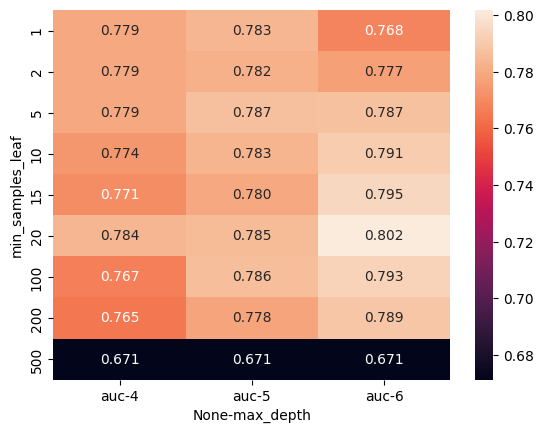

In [306]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

In [307]:
dt = DecisionTreeClassifier(max_depth=6,min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

6.6 Ensembles and random forest
- Board of experts
- Ensembling models
- Random forest- ensembling decision trees
- Tuning random forest

In [308]:
from sklearn.ensemble import RandomForestClassifier

In [309]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [310]:
y_pred = rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val,y_pred)

0.8135545556805399

In [311]:
rf.predict_proba(X_val[[0]])

array([[1., 0.]])

In [312]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    
    scores.append((n, auc))

In [313]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

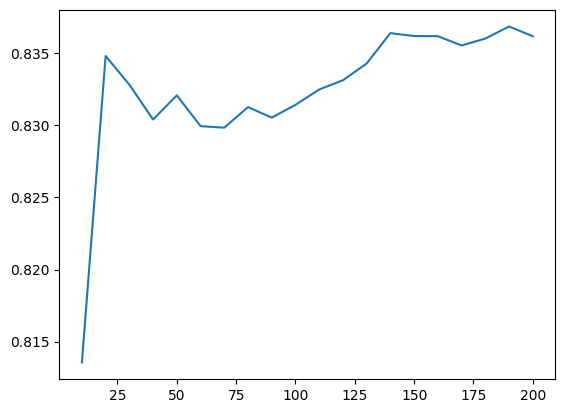

In [314]:
plt.plot(df_scores.n_estimators,df_scores.auc)

In [315]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, n, auc))

In [316]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

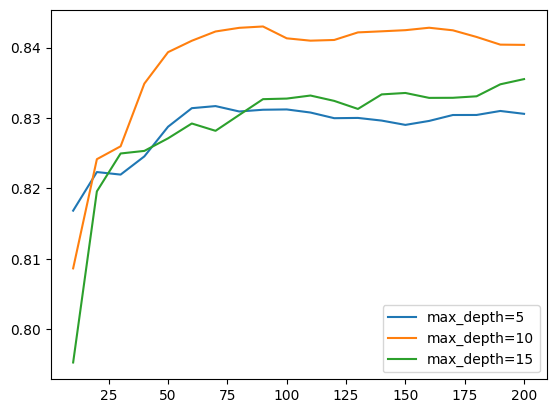

In [317]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)

plt.legend()

In [318]:
max_depth = 10

In [319]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))

In [320]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

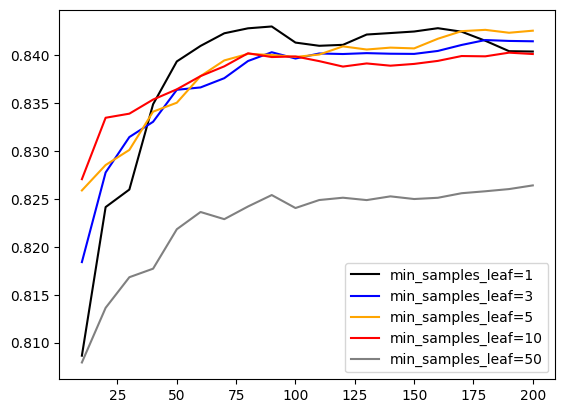

In [321]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
values = [1, 3, 5, 10, 50]

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

In [322]:
min_samples_leaf = 3

In [323]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

6.7 Gradient boosting and XGboost

- Gradient boosting vs random forest
- Installing XGBoost
- Training the first model
- Performance monitoring
- Parsing xgboost's monitoring output 

In [324]:
#!pip install xgboost

In [325]:
import xgboost as xgb

In [326]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)


In [327]:
xgb_params ={
'eta' : 0.3,
'max_depth':6,
'min_child_weight':1,
'objective':'binary:logistic',
'nthread': 8,
'seed':1,
'verbosity':1

}

model=xgb.train(xgb_params,dtrain,num_boost_round=200)

In [328]:
model.predict(dval)

array([2.09570630e-03, 7.14903045e-03, 1.67857483e-02, 4.39920396e-01,
       9.94738042e-01, 9.09845173e-01, 4.07280587e-03, 2.65098922e-02,
       8.27427357e-02, 5.65270260e-02, 3.35580289e-01, 4.55454677e-01,
       1.51402235e-01, 2.14589164e-01, 7.25075509e-03, 6.93330616e-02,
       4.27157339e-03, 6.26230240e-01, 5.24388254e-02, 2.70978868e-01,
       1.78179294e-01, 8.58196318e-01, 2.70200539e-02, 3.13092828e-01,
       8.81566346e-01, 9.69975293e-01, 7.26124458e-03, 8.62467289e-02,
       6.26810128e-04, 5.03984571e-01, 7.98321608e-03, 6.59888005e-03,
       9.79785502e-01, 9.21256483e-01, 5.10467333e-04, 5.86280107e-01,
       2.28489697e-01, 9.75500762e-01, 1.77175030e-01, 9.37896371e-01,
       5.28353639e-03, 5.27131796e-01, 7.55526405e-03, 3.73996161e-02,
       9.68353271e-01, 3.86697263e-01, 1.21806646e-04, 6.18450522e-01,
       3.56933594e-01, 5.40895201e-02, 9.37834203e-01, 3.04338168e-02,
       7.52518773e-01, 3.77190746e-02, 1.69162378e-01, 1.61673985e-02,
      

In [329]:
roc_auc_score(y_val,y_pred)

0.8264070013226368

In [330]:
watchlist =[(dtrain,'train'),(dval,'val')]

In [331]:
xgb_params ={
'eta' : 0.3,
'max_depth':6,
'min_child_weight':1,
'objective':'binary:logistic',
'eval_metric':'auc',
'nthread': 8,
'seed':1,
'verbosity':1

}

model=xgb.train(xgb_params,dtrain,num_boost_round=200,evals=watchlist)

[0]	train-auc:0.85945	val-auc:0.79388
[1]	train-auc:0.88516	val-auc:0.80503
[2]	train-auc:0.89806	val-auc:0.81163
[3]	train-auc:0.90636	val-auc:0.81456
[4]	train-auc:0.91874	val-auc:0.82017
[5]	train-auc:0.92831	val-auc:0.82671
[6]	train-auc:0.93286	val-auc:0.82815
[7]	train-auc:0.94052	val-auc:0.82612
[8]	train-auc:0.94393	val-auc:0.82696
[9]	train-auc:0.94702	val-auc:0.82823
[10]	train-auc:0.94937	val-auc:0.82753
[11]	train-auc:0.95365	val-auc:0.82689
[12]	train-auc:0.95612	val-auc:0.82722
[13]	train-auc:0.95832	val-auc:0.82748
[14]	train-auc:0.96123	val-auc:0.82800
[15]	train-auc:0.96295	val-auc:0.82831
[16]	train-auc:0.96435	val-auc:0.82850
[17]	train-auc:0.96699	val-auc:0.82814
[18]	train-auc:0.96894	val-auc:0.82745
[19]	train-auc:0.97070	val-auc:0.82661
[20]	train-auc:0.97147	val-auc:0.82688
[21]	train-auc:0.97277	val-auc:0.82793
[22]	train-auc:0.97361	val-auc:0.82714
[23]	train-auc:0.97594	val-auc:0.82681
[24]	train-auc:0.97645	val-auc:0.82602
[25]	train-auc:0.97790	val-auc:0.82

In [332]:
%%capture output

xgb_params ={
'eta' : 0.3,
'max_depth':6,
'min_child_weight':1,
'objective':'binary:logistic',
'eval_metric':'auc',
'nthread': 8,
'seed':1,
'verbosity':1

}

model=xgb.train(xgb_params,dtrain,num_boost_round=200,verbose_eval=5,evals=watchlist,early_stopping_rounds=10)

In [333]:
s = output.stdout

In [334]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [335]:
df_score = parse_xgb_output(output)

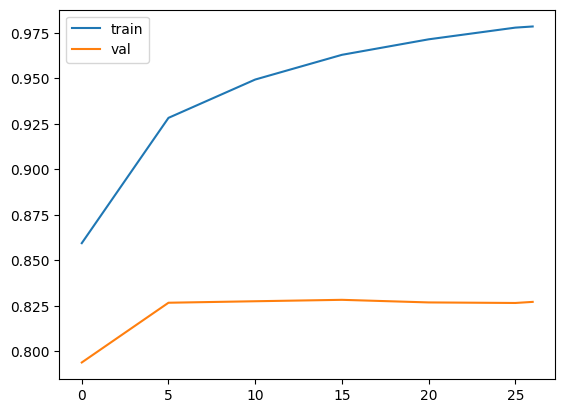

In [336]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

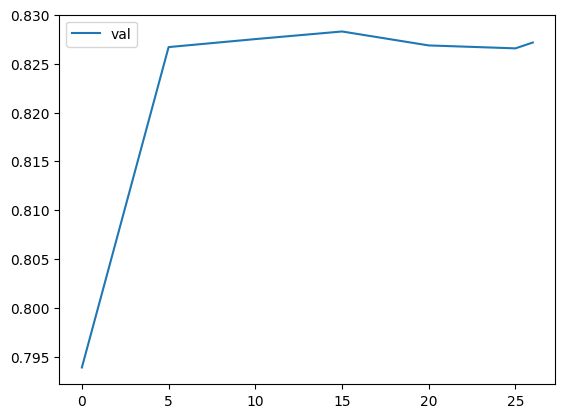

In [337]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

6.8 XGboost parameter tuning

Tuning the following parameters:

- eta
- max_depth
- min_child_weight

scores = {}

In [338]:
%%capture output

xgb_params = {
    'eta': 0.01, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [339]:
scores = {}

In [340]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.01'

In [341]:
scores = {}

In [342]:
%%capture output

xgb_params = {
    'eta': 0.1, 
    'max_depth': 10,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)


max_depth = 3
[0]	train-auc:0.76651	val-auc:0.76295
[5]	train-auc:0.85480	val-auc:0.82371
[10]	train-auc:0.87560	val-auc:0.83485
[15]	train-auc:0.88803	val-auc:0.83648


[20]	train-auc:0.89588	val-auc:0.83910
[25]	train-auc:0.90166	val-auc:0.83788
[29]	train-auc:0.90694	val-auc:0.83794

max_depth = 4
[0]	train-auc:0.80656	val-auc:0.77852
[5]	train-auc:0.87908	val-auc:0.82702
[10]	train-auc:0.90174	val-auc:0.83584
[15]	train-auc:0.91489	val-auc:0.83803
[20]	train-auc:0.92320	val-auc:0.84097
[25]	train-auc:0.93099	val-auc:0.84114
[29]	train-auc:0.93778	val-auc:0.83922

max_depth = 6
[0]	train-auc:0.85945	val-auc:0.79388
[5]	train-auc:0.92831	val-auc:0.82671
[10]	train-auc:0.94937	val-auc:0.82753
[15]	train-auc:0.96295	val-auc:0.82831
[20]	train-auc:0.97147	val-auc:0.82688
[25]	train-auc:0.97790	val-auc:0.82658
[29]	train-auc:0.98314	val-auc:0.82421

max_depth = 10
[0]	train-auc:0.92152	val-auc:0.79621
[5]	train-auc:0.98469	val-auc:0.82911
[10]	train-auc:0.99628	val-auc:0.82876
[15]	train-auc:0.99893	val-auc:0.83186
[20]	train-auc:0.99967	val-auc:0.83110
[25]	train-auc:0.99997	val-auc:0.82801
[29]	train-auc:0.99999	val-auc:0.82608


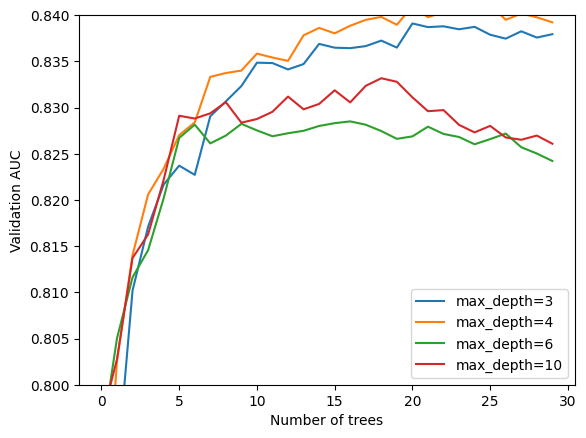

In [343]:
scores = {}

for max_depth in [3, 4, 6, 10]:
    print(f'\nmax_depth = {max_depth}')

    xgb_params = {
        'eta': 0.3,
        'max_depth': max_depth,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1
    }

    evals_result = {}

    model = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=30,
        evals=watchlist,
        verbose_eval=5,
        evals_result=evals_result
    )

    df_score = pd.DataFrame({
        'num_iter': range(len(evals_result['train']['auc'])),
        'train_auc': evals_result['train']['auc'],
        'val_auc': evals_result['val']['auc']
    })

    scores[max_depth] = df_score


for max_depth, df_score in scores.items():
    plt.plot(df_score['num_iter'], df_score['val_auc'], label=f'max_depth={max_depth}')

plt.xlabel('Number of trees')
plt.ylabel('Validation AUC')
plt.ylim(0.8, 0.84)
plt.legend()
plt.show()

6.8 XGBoost Parameter Tuning

- eta: Learning rate
- max_depth: 
- min_child_weight

In [344]:
%%capture output
xgb_params = {
    'eta': 0.3, 
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,verbose_eval=5,evals=watchlist)

In [345]:
scores = {}

In [346]:
key ='eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

In [347]:
scores['eta=0.3']

,num_iter,train_auc,val_auc
0,0,0.76651,0.76295
1,5,0.85480,0.82371
2,10,0.87560,0.83485
3,15,0.88803,0.83648
4,20,0.89588,0.83910
5,25,0.90166,0.83788
6,30,0.90793,0.83682
7,35,0.91315,0.83525
8,40,0.91809,0.83440
9,45,0.92288,0.83296


In [348]:
%%capture output
xgb_params = {
    'eta': 1.0, 
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,verbose_eval=5,evals=watchlist)

In [349]:
scores = {}

In [350]:
key ='eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

In [351]:
scores['eta=1.0']

,num_iter,train_auc,val_auc
0,0,0.76651,0.76295
1,5,0.87334,0.81682
2,10,0.89538,0.81746
3,15,0.90991,0.81833
4,20,0.92206,0.81984
5,25,0.93340,0.81755
6,30,0.94321,0.81119
7,35,0.95168,0.80957
8,40,0.95760,0.81089
9,45,0.96317,0.80784


In [352]:
%%capture output
xgb_params = {
    'eta': 0.1, 
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,verbose_eval=5,evals=watchlist) 
scores = {}

key ='eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
scores['eta=0.1']




In [353]:
%%capture output
xgb_params = {
    'eta': 0.05, 
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,verbose_eval=5,evals=watchlist) 
scores = {}

key ='eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
scores['eta=0.05']




In [354]:
%%capture output
xgb_params = {
    'eta': 0.01, 
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,verbose_eval=5,evals=watchlist) 
scores = {}

key ='eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
scores['eta=0.01']




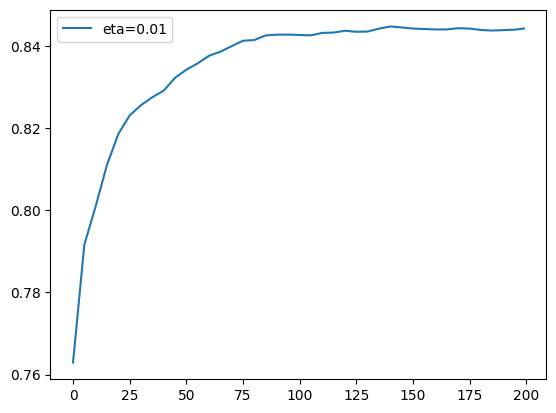

In [355]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)
    plt.legend()


In [356]:
def parse_xgb_output(output):
    results = []

    for line in output.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train_auc = float(train_line.split(':')[1])
        val_auc = float(val_line.split(':')[1])

        results.append((it, train_auc, val_auc))

    columns = ['iter', 'train_auc', 'val_auc']
    return pd.DataFrame(results, columns=columns)

In [357]:
from IPython.utils.io import capture_output

In [358]:
scores = {}

for eta in [0.01, 0.05, 0.1, 0.3, 1.0]:
    print(f'eta={eta}')

    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'seed': 1,
        'verbosity': 1
    }

    with capture_output() as captured:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=[(dtrain, 'train'), (dval, 'validation')],
            verbose_eval=5
        )

    scores[eta] = parse_xgb_output(captured.stdout)

eta=0.01
eta=0.05
eta=0.1
eta=0.3
eta=1.0


In [359]:
from IPython.utils.io import capture_output

scores = {}

for eta in [0.01, 0.05, 0.1, 0.3, 1.0]:

    print(f'eta={eta}')

    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'seed': 1,
        'verbosity': 1
    }

    with capture_output() as captured:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=[(dtrain, 'train'), (dval, 'validation')],
            verbose_eval=5
        )

    scores[eta] = parse_xgb_output(captured.stdout)

eta=0.01
eta=0.05
eta=0.1
eta=0.3
eta=1.0


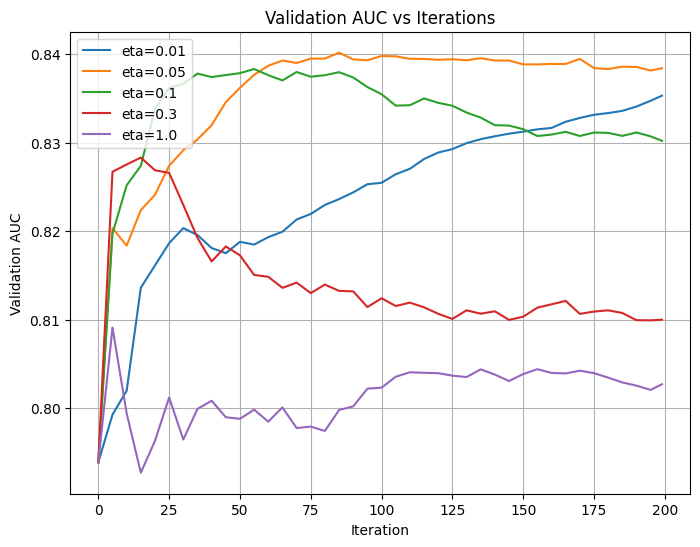

In [360]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for eta, df_score in scores.items():
    plt.plot(df_score.iter, df_score.val_auc, label=f'eta={eta}')

plt.xlabel('Iteration')
plt.ylabel('Validation AUC')
plt.title('Validation AUC vs Iterations')
plt.legend()
plt.grid(True)

plt.show()

In [361]:
scores = {}

for max_depth in [3, 4, 6, 8, 10]:
    xgb_params = {
        'eta': 0.1, 
        'max_depth': max_depth,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }

    with capture_output() as captured:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            verbose_eval=5,
            evals=watchlist
        )

    key = f'max_depth={max_depth}'
    scores[key] = parse_xgb_output(captured.stdout)

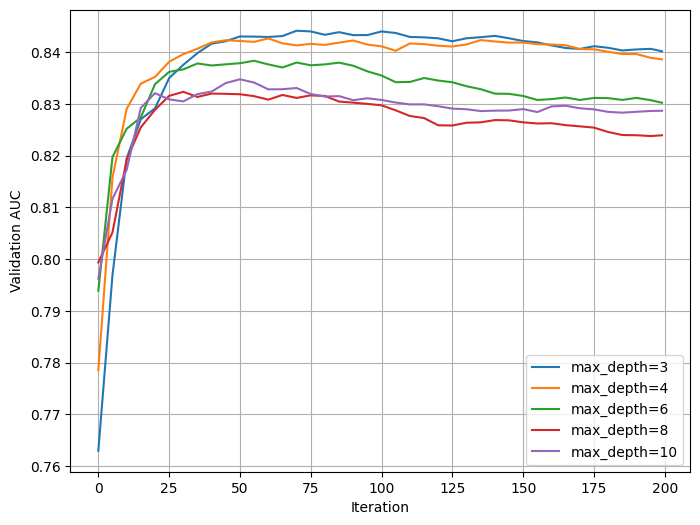

In [362]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for key, df_score in scores.items():
    plt.plot(df_score.iter, df_score.val_auc, label=key)

plt.xlabel('Iteration')
plt.ylabel('Validation AUC')
plt.legend()
plt.grid(True)
plt.show()

In [363]:
scores = {}

for max_depth in [3, 4, 6]:
    xgb_params = {
        'eta': 0.1, 
        'max_depth': max_depth,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }

    with capture_output() as captured:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            verbose_eval=5,
            evals=watchlist
        )

    key = f'max_depth={max_depth}'
    scores[key] = parse_xgb_output(captured.stdout)

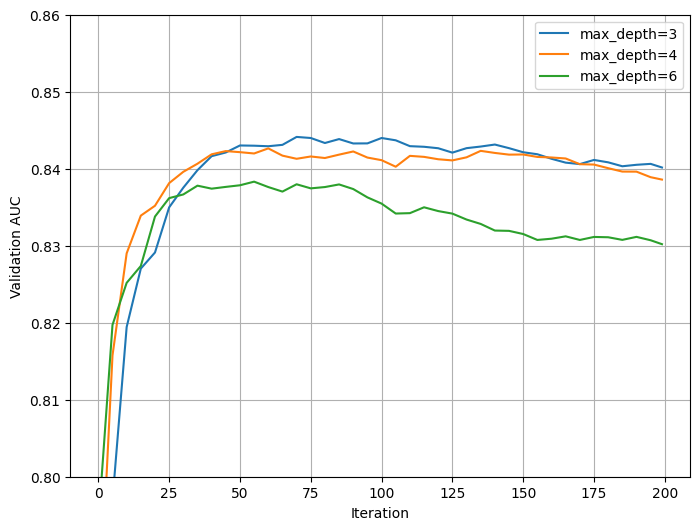

In [364]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for key, df_score in scores.items():
    plt.plot(df_score.iter, df_score.val_auc, label=key)
    plt.ylim(0.8,0.86)

plt.xlabel('Iteration')
plt.ylabel('Validation AUC')
plt.legend()
plt.grid(True)
plt.show()

In [365]:
from IPython.utils.io import capture_output

scores = {}

for min_child_weight in [1, 5, 10, 30]:

    print(f'min_child_weight={min_child_weight}')

    xgb_params = {
        'eta': 0.1,
        'max_depth': 3,
        'min_child_weight': min_child_weight,

        'objective': 'binary:logistic',
        'eval_metric': 'auc',

        'nthread': 8,
        'seed': 1,
        'verbosity': 1
    }

    with capture_output() as captured:
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=watchlist,
            verbose_eval=5
        )

    key = f'min_child_weight={min_child_weight}'
    scores[key] = parse_xgb_output(captured.stdout)

min_child_weight=1
min_child_weight=5
min_child_weight=10
min_child_weight=30


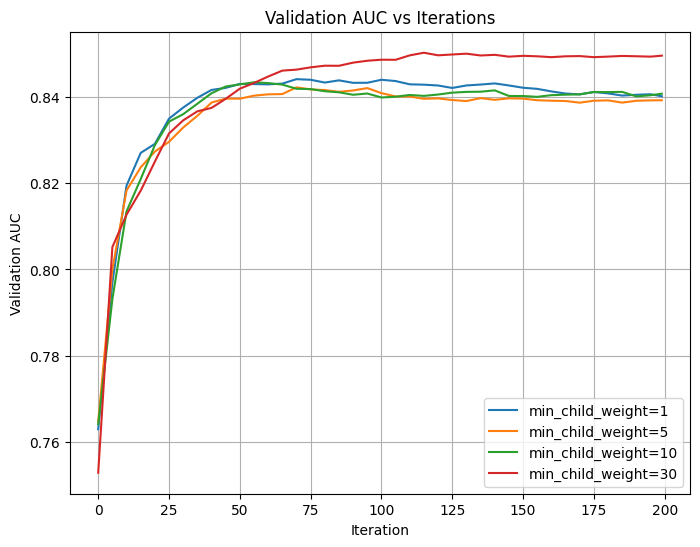

In [366]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for key, df_score in scores.items():
    plt.plot(df_score.iter, df_score.val_auc, label=key)

plt.xlabel('Iteration')
plt.ylabel('Validation AUC')
plt.title('Validation AUC vs Iterations')
plt.legend()
plt.grid(True)

plt.show()

In [367]:
for key, df_score in scores.items():
    print(key, df_score.val_auc.max())

min_child_weight=1 0.84413
min_child_weight=5 0.84223
min_child_weight=10 0.8434
min_child_weight=30 0.85026


Grid Search (systematic search)

You define a grid of parameters, and the algorithm tests all combinations.

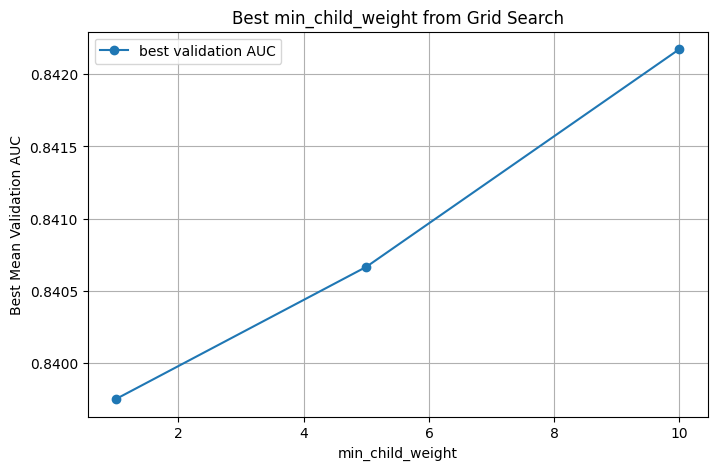

In [368]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

best_scores = (
    results.groupby('param_min_child_weight')['mean_test_score']
    .max()
    .reset_index()
    .sort_values('param_min_child_weight')
)

plt.figure(figsize=(8, 5))
plt.plot(
    best_scores['param_min_child_weight'],
    best_scores['mean_test_score'],
    marker='o',
    label='best validation AUC'
)

plt.xlabel('min_child_weight')
plt.ylabel('Best Mean Validation AUC')
plt.title('Best min_child_weight from Grid Search')
plt.legend()
plt.grid(True)
plt.show()

In [369]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=1
)

param_grid = {
    'max_depth': [3, 4, 6],
    'min_child_weight': [1, 5, 10],
    'eta': [0.01, 0.1, 0.3]
}

grid = GridSearchCV(
    model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..........eta=0.01, max_depth=3, min_child_weight=1; total time=   0.1s
[CV] END ..........eta=0.01, max_depth=3, min_child_weight=1; total time=   0.1s
[CV] END ..........eta=0.01, max_depth=3, min_child_weight=1; total time=   0.1s
[CV] END ..........eta=0.01, max_depth=3, min_child_weight=5; total time=   0.1s
[CV] END ..........eta=0.01, max_depth=3, min_child_weight=5; total time=   0.1s
[CV] END ..........eta=0.01, max_depth=3, min_child_weight=5; total time=   0.0s
[CV] END .........eta=0.01, max_depth=3, min_child_weight=10; total time=   0.0s
[CV] END .........eta=0.01, max_depth=3, min_child_weight=10; total time=   0.1s
[CV] END .........eta=0.01, max_depth=3, min_child_weight=10; total time=   0.0s
[CV] END ..........eta=0.01, max_depth=4, min_child_weight=1; total time=   0.1s
[CV] END ..........eta=0.01, max_depth=4, min_child_weight=1; total time=   0.1s
[CV] END ..........eta=0.01, max_depth=4, min_ch

Random Search (better than grid)

Instead of testing all combinations, it randomly samples parameter combinations.

In [370]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3,4,5,6,8],
    'min_child_weight': [1,5,10,20],
    'eta': [0.01,0.05,0.1,0.2,0.3]
}

random_search = RandomizedSearchCV(
    model,
    param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

{'min_child_weight': 20, 'max_depth': 8, 'eta': 0.05}


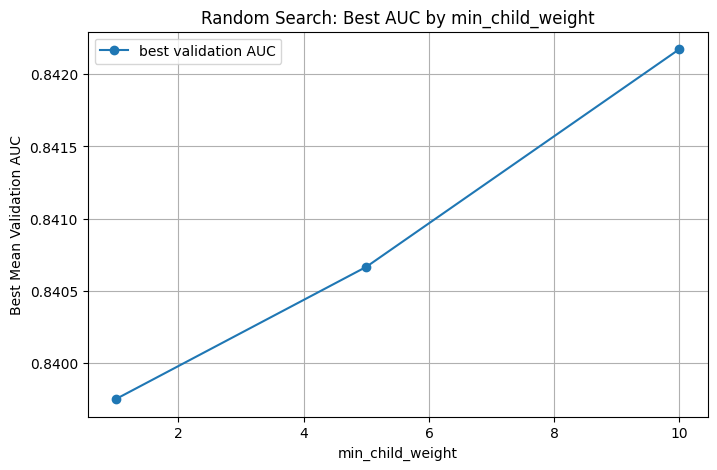

In [371]:
import matplotlib.pyplot as plt

best_by_weight = (
    results.groupby('param_min_child_weight')['mean_test_score']
    .max()
    .reset_index()
    .sort_values('param_min_child_weight')
)

plt.figure(figsize=(8,5))

plt.plot(
    best_by_weight['param_min_child_weight'],
    best_by_weight['mean_test_score'],
    marker='o',
    label='best validation AUC'
)

plt.xlabel('min_child_weight')
plt.ylabel('Best Mean Validation AUC')
plt.title('Random Search: Best AUC by min_child_weight')

plt.legend()
plt.grid(True)

plt.show()

6.9 Selecting the final model
- Choosing between xgboost and random forest and decision tree
- Training the final model
- Saving the model

In [372]:
dt = DecisionTreeClassifier(max_depth=6,min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [374]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [376]:
xgb_params = {
        'eta': 0.1,
        'max_depth': 3,
        'min_child_weight': 30,

        'objective': 'binary:logistic',
        'eval_metric': 'auc',

        'nthread': 8,
        'seed': 1,
        'verbosity': 1
    }

model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=175,
            evals=watchlist,
            verbose_eval=5
        )

[0]	train-auc:0.75809	val-auc:0.75287
[5]	train-auc:0.82093	val-auc:0.80519
[10]	train-auc:0.83440	val-auc:0.81271
[15]	train-auc:0.84460	val-auc:0.81826
[20]	train-auc:0.85258	val-auc:0.82500
[25]	train-auc:0.85876	val-auc:0.83155
[30]	train-auc:0.86307	val-auc:0.83457
[35]	train-auc:0.86576	val-auc:0.83667
[40]	train-auc:0.86773	val-auc:0.83746
[45]	train-auc:0.87103	val-auc:0.83957
[50]	train-auc:0.87430	val-auc:0.84192
[55]	train-auc:0.87650	val-auc:0.84324
[60]	train-auc:0.87817	val-auc:0.84474
[65]	train-auc:0.87941	val-auc:0.84611
[70]	train-auc:0.88058	val-auc:0.84634
[75]	train-auc:0.88132	val-auc:0.84687
[80]	train-auc:0.88229	val-auc:0.84725
[85]	train-auc:0.88310	val-auc:0.84723
[90]	train-auc:0.88408	val-auc:0.84796
[95]	train-auc:0.88505	val-auc:0.84840
[100]	train-auc:0.88568	val-auc:0.84864
[105]	train-auc:0.88675	val-auc:0.84862
[110]	train-auc:0.88750	val-auc:0.84965
[115]	train-auc:0.88841	val-auc:0.85026
[120]	train-auc:0.88913	val-auc:0.84966
[125]	train-auc:0.8899

In [377]:
y_pred = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_val,y_pred)

0.7947317024932322

In [378]:
y_pred = rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val,y_pred)

0.8414442700156985

In [379]:
y_pred = model.predict(dval)
roc_auc_score(y_val,y_pred)

0.8492997441253908

In [385]:
df_full_train = df_full_train.reset_index(drop=True)
df_full_train

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,6,other,30,22,single,no,fixed,35,73.0,0.0,0.0,1086,1086
1,ok,45,owner,30,64,married,no,freelance,45,157.0,20000.0,0.0,1000,1588
2,ok,2,owner,60,30,married,yes,fixed,45,174.0,4000.0,0.0,2000,2250
3,ok,11,rent,60,28,married,no,fixed,59,144.0,0.0,0.0,1225,1360
4,ok,2,parents,36,19,married,no,fixed,35,162.0,4000.0,100.0,400,570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559,default,4,owner,60,47,married,no,freelance,75,0.0,13500.0,0.0,1900,1976
3560,ok,2,rent,60,28,single,no,fixed,45,101.0,0.0,0.0,1300,1333
3561,default,24,other,60,41,married,yes,freelance,75,0.0,0.0,0.0,2200,2428
3562,default,2,rent,48,56,single,no,freelance,51,157.0,11000.0,4500.0,1000,2008


In [386]:
y_full_train = (df_full_train.status == 'default').astype(int).values

In [387]:
y_full_train

array([0, 0, 0, ..., 1, 1, 1], shape=(3564,))

In [388]:
del df_full_train['status']

In [ ]:
dicts_full_train = df_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)


dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [390]:
y_test

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,

In [396]:
dfulltrain = xgb.DMatrix(
    X_full_train,
    label=y_full_train,
    feature_names=list(dv.get_feature_names_out())
)

dtest = xgb.DMatrix(
    X_test,
    feature_names=list(dv.get_feature_names_out())
)

In [397]:
xgb_params = {
        'eta': 0.1,
        'max_depth': 3,
        'min_child_weight': 1,

        'objective': 'binary:logistic',
        'eval_metric': 'auc',

        'nthread': 8,
        'seed': 1,
        'verbosity': 1
    }

model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=175
        )

In [407]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
import xgboost as xgb

categorical = ['job', 'marital', 'home', 'records']
numerical = ['seniority', 'time', 'age', 'expenses', 'income', 'assets', 'debt', 'amount', 'price']

dv = DictVectorizer(sparse=True)

full_train_dicts = df_full_train[categorical + numerical].to_dict(orient='records')
test_dicts = df_test[categorical + numerical].to_dict(orient='records')

X_full_train = dv.fit_transform(full_train_dicts)
X_test = dv.transform(test_dicts)

feature_names = list(dv.get_feature_names_out())

dfulltrain = xgb.DMatrix(
    X_full_train,
    label=y_full_train,
    feature_names=feature_names
)

dtest = xgb.DMatrix(
    X_test,
    feature_names=feature_names
)

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1
}

final_model = xgb.train(
    xgb_params,
    dfulltrain,
    num_boost_round=160
)

y_pred = final_model.predict(dtest)

In [408]:
auc = roc_auc_score(y_test, y_pred)
print(auc)

0.8330305167405778


In [409]:
y_pred = final_model.predict(dtest)